In [43]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import defaultdict

DATA_PATH = "logs/mbe_dynamics_base.jsonl"

records = []
with open(DATA_PATH) as f:
    for line in f:
        records.append(json.loads(line))

print(f"Loaded {len(records)} records")
print(f"Steps: {sorted(set(r['step'] for r in records))[0]} – {sorted(set(r['step'] for r in records))[-1]}")
print(f"Correct: {sum(r['correct'] for r in records)} / {len(records)}")

Loaded 832 records
Steps: 5 – 840
Correct: 215 / 832


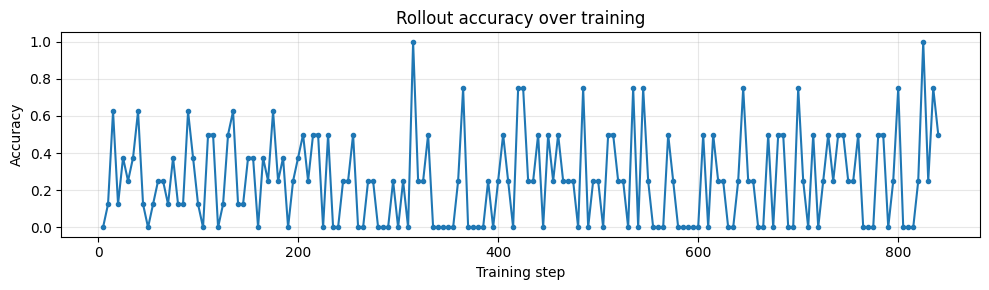

In [44]:
# Accuracy per step
step_correct = defaultdict(list)
for r in records:
    step_correct[r['step']].append(int(r['correct']))

steps_sorted = sorted(step_correct.keys())
acc = [np.mean(step_correct[s]) for s in steps_sorted]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(steps_sorted, acc, 'o-', markersize=3)
ax.set_xlabel('Training step')
ax.set_ylabel('Accuracy')
ax.set_title('Rollout accuracy over training')
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

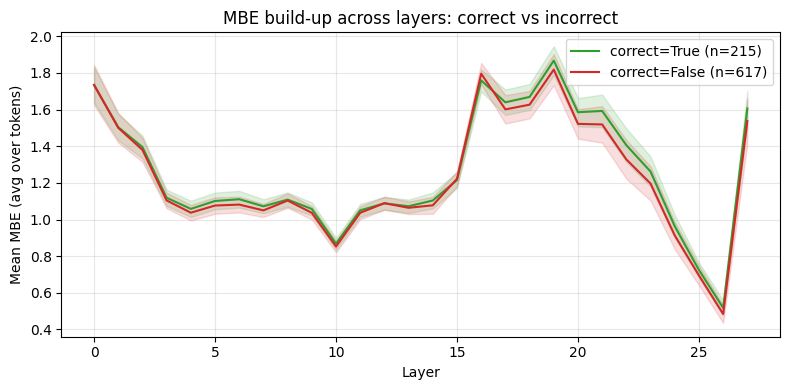

In [45]:
mbe_by_correct = {True: [], False: []}
for r in records:
    # mean over token positions for each layer
    layer_means = np.array(r['mbe']).mean(axis=1)  # shape (28,)
    mbe_by_correct[r['correct']].append(layer_means)

fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [(True, 'tab:green'), (False, 'tab:red')]:
    arr = np.array(mbe_by_correct[label])
    mean = arr.mean(axis=0)
    std = arr.std(axis=0)
    layers = np.arange(len(mean))
    ax.plot(layers, mean, color=color, label=f'correct={label} (n={len(arr)})')
    ax.fill_between(layers, mean - std, mean + std, alpha=0.15, color=color)

ax.set_xlabel('Layer')
ax.set_ylabel('Mean MBE (avg over tokens)')
ax.set_title('MBE build-up across layers: correct vs incorrect')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

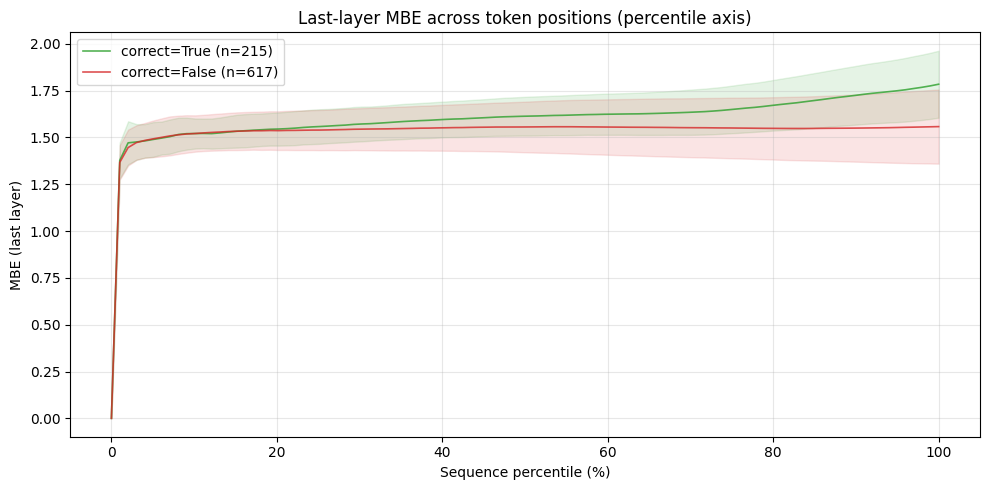

In [50]:
PCT_GRID = 100
PCT_AXIS = np.linspace(0, 100, PCT_GRID)

def to_pct_1d(arr):
    """Resample a 1-D array of any length onto a shared percentile grid."""
    src = np.linspace(0, 100, len(arr))
    return np.interp(PCT_AXIS, src, arr)

fig, ax = plt.subplots(figsize=(10, 5))
for label, color in [(True, 'tab:green'), (False, 'tab:red')]:
    last_layer = [to_pct_1d(np.array(r['mbe'])[-1]) for r in records if r['correct'] == label]
    arr = np.stack(last_layer)   # (n_samples, PCT_GRID) — all same length now
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    ax.plot(PCT_AXIS, mean, color=color, alpha=0.8,
            label=f'correct={label} (n={len(arr)})', linewidth=1.2)
    ax.fill_between(PCT_AXIS, mean - std, mean + std, alpha=0.12, color=color)

ax.set_xlabel('Sequence percentile (%)')
ax.set_ylabel('MBE (last layer)')
ax.set_title('Last-layer MBE across token positions (percentile axis)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

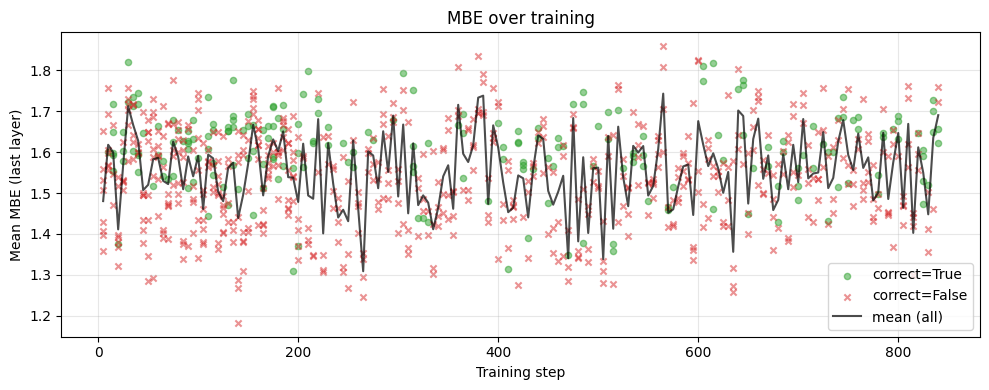

In [47]:
step_mbe = defaultdict(lambda: {True: [], False: []})
for r in records:
    val = np.mean(np.array(r['mbe'])[-1])
    step_mbe[r['step']][r['correct']].append(val)

fig, ax = plt.subplots(figsize=(10, 4))
for label, color, marker in [(True, 'tab:green', 'o'), (False, 'tab:red', 'x')]:
    xs, ys = [], []
    for s in steps_sorted:
        for v in step_mbe[s][label]:
            xs.append(s)
            ys.append(v)
    ax.scatter(xs, ys, c=color, marker=marker, alpha=0.5, s=20, label=f'correct={label}')

# overlay per-step means (all samples)
step_mbe_all = defaultdict(list)
for r in records:
    step_mbe_all[r['step']].append(np.mean(np.array(r['mbe'])[-1]))
means = [np.mean(step_mbe_all[s]) for s in steps_sorted]
ax.plot(steps_sorted, means, 'k-', linewidth=1.5, alpha=0.7, label='mean (all)')

ax.set_xlabel('Training step')
ax.set_ylabel('Mean MBE (last layer)')
ax.set_title('MBE over training')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [48]:
percentiles = np.arange(0, 101, 5)  # 0, 5, 10, ..., 100

def mbe_at_percentiles(mbe_last_layer, pcts):
    """Given a 1-D MBE curve (variable length), return MBE values at given percentile positions."""
    n = len(mbe_last_layer)
    indices = np.clip(np.round(pcts / 100.0 * (n - 1)).astype(int), 0, n - 1)
    return np.array(mbe_last_layer)[indices]

# Compute velocity (MBE[p] - MBE[0]) for each sample
velocities = {True: [], False: []}
mbe_curves = {True: [], False: []}
for r in records:
    last = np.array(r['mbe'])[-1]
    vals = mbe_at_percentiles(last, percentiles)
    velocity = vals - vals[0]  # subtract 0th percentile
    velocities[r['correct']].append(velocity)
    mbe_curves[r['correct']].append(vals)

print(f"Correct samples: {len(velocities[True])}, Incorrect: {len(velocities[False])}")
print(f"Percentile grid: {percentiles}")

Correct samples: 215, Incorrect: 617
Percentile grid: [  0   5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85
  90  95 100]


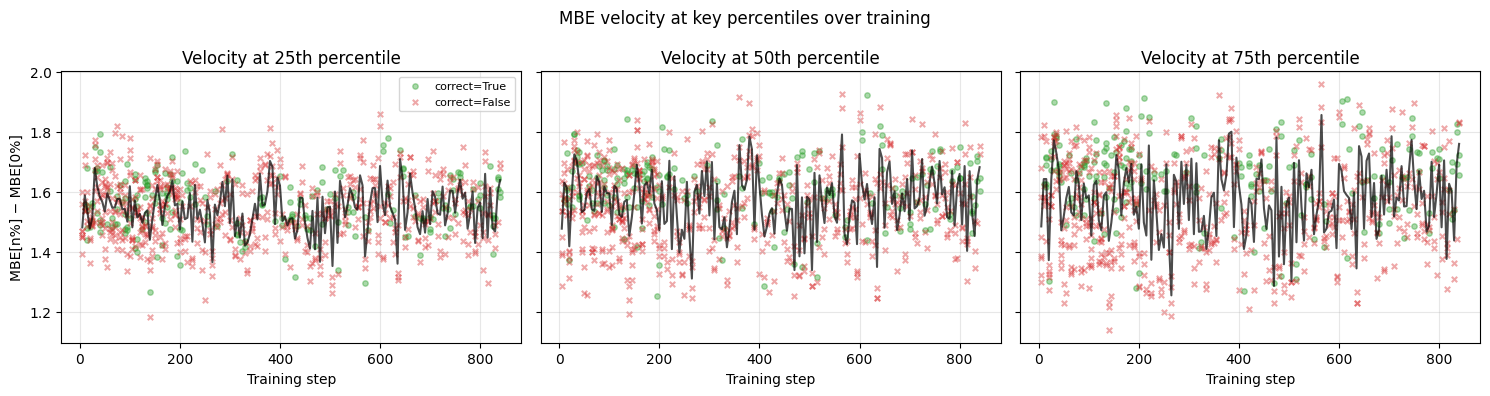

In [51]:
milestone_pcts = [25, 50, 75]
pct_to_idx = {p: np.argmin(np.abs(percentiles - p)) for p in milestone_pcts}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, pct in zip(axes, milestone_pcts):
    idx = pct_to_idx[pct]
    step_vel = defaultdict(lambda: {True: [], False: []})
    for r, vel_arr in zip(records, [velocities[r['correct']] for r in records]):
        pass  # need to recompute per-record

    # recompute cleanly
    step_vel = defaultdict(lambda: {True: [], False: []})
    for r in records:
        last = np.array(r['mbe'])[-1]
        vals = mbe_at_percentiles(last, percentiles)
        v = vals[idx] - vals[0]
        step_vel[r['step']][r['correct']].append(v)

    for label, color, marker in [(True, 'tab:green', 'o'), (False, 'tab:red', 'x')]:
        xs, ys = [], []
        for s in steps_sorted:
            for v in step_vel[s][label]:
                xs.append(s)
                ys.append(v)
        ax.scatter(xs, ys, c=color, marker=marker, alpha=0.4, s=15, label=f'correct={label}')

    # mean line (all)
    all_means = []
    for s in steps_sorted:
        all_vals = step_vel[s][True] + step_vel[s][False]
        all_means.append(np.mean(all_vals) if all_vals else np.nan)
    ax.plot(steps_sorted, all_means, 'k-', linewidth=1.5, alpha=0.7)

    ax.set_xlabel('Training step')
    ax.set_title(f'Velocity at {pct}th percentile')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('MBE[n%] − MBE[0%]')
axes[0].legend(fontsize=8)
plt.suptitle('MBE velocity at key percentiles over training')
plt.tight_layout()
plt.show()

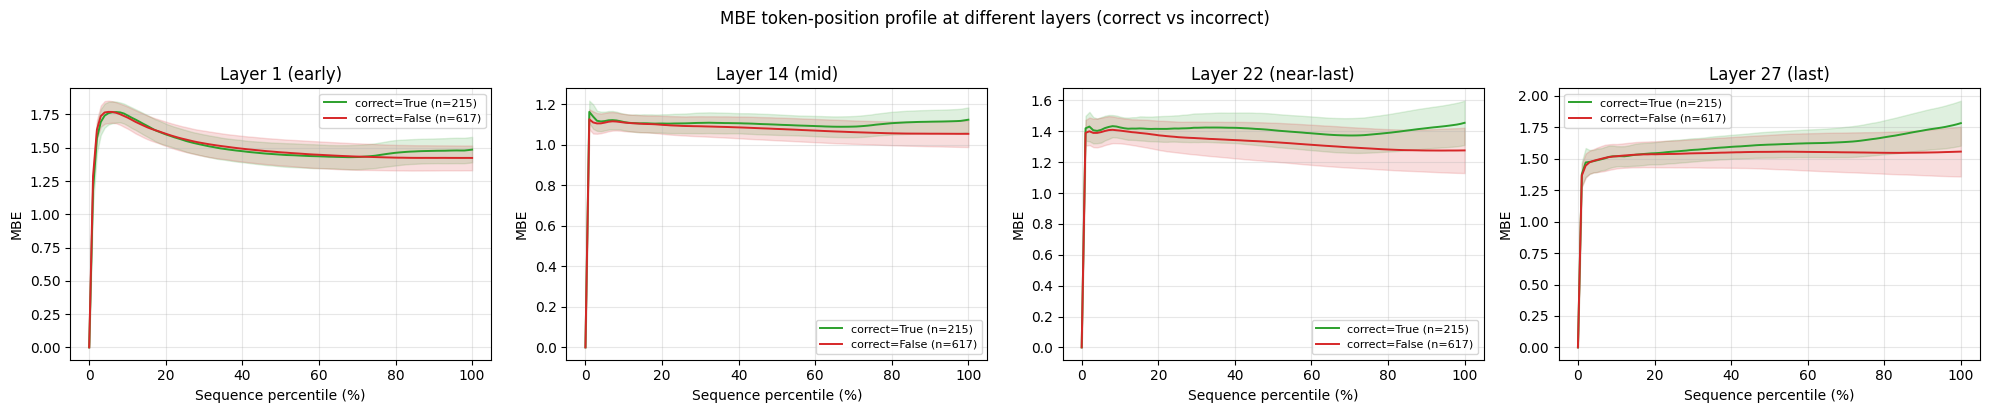

In [52]:

# ── Mid-layer vs last-layer MBE profile ──────────────────────────────────────
# 28 layers (0–27): compare early / mid / near-last / last
layer_configs = [
    ('Layer 1 (early)',    1),
    ('Layer 14 (mid)',    14),
    ('Layer 22 (near-last)', 22),
    ('Layer 27 (last)',   27),
]

fig, axes = plt.subplots(1, len(layer_configs), figsize=(20, 4), sharey=False)

for ax, (title, li) in zip(axes, layer_configs):
    for label, color in [(True, 'tab:green'), (False, 'tab:red')]:
        curves = [to_pct_1d(np.array(r['mbe'])[li]) for r in records if r['correct'] == label]
        arr  = np.stack(curves)
        mean = arr.mean(axis=0)
        std  = arr.std(axis=0)
        ax.plot(PCT_AXIS, mean, color=color, linewidth=1.4,
                label=f'correct={label} (n={len(arr)})')
        ax.fill_between(PCT_AXIS, mean - std, mean + std, alpha=0.15, color=color)

    ax.set_xlabel('Sequence percentile (%)')
    ax.set_ylabel('MBE')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('MBE token-position profile at different layers (correct vs incorrect)', y=1.02)
plt.tight_layout()
plt.show()


correct=True   n= 215  mean= 895.2  median=   941  std=140.8  min=432  max=1024
correct=False  n= 617  mean=1023.1  median=  1024  std= 11.5  min=833  max=1025


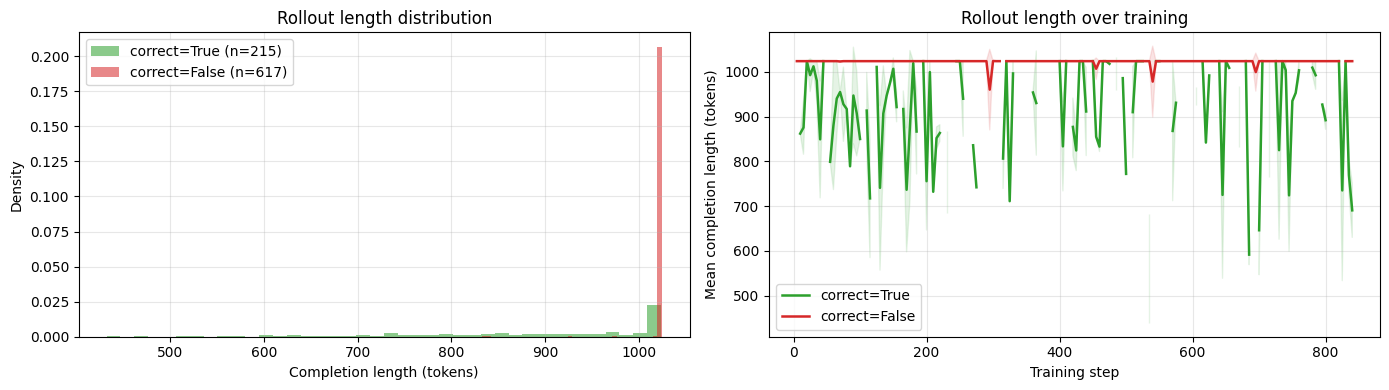

In [53]:

# ── Rollout length: correct vs incorrect ─────────────────────────────────────
len_by_correct = {True: [], False: []}
for r in records:
    len_by_correct[r['correct']].append(r['n_tokens'])

# summary stats
for label in [True, False]:
    v = len_by_correct[label]
    print(f"correct={str(label):5s}  n={len(v):4d}  "
          f"mean={np.mean(v):6.1f}  median={np.median(v):6.0f}  "
          f"std={np.std(v):5.1f}  min={min(v)}  max={max(v)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- panel 1: histogram ---
ax = axes[0]
for label, color in [(True, 'tab:green'), (False, 'tab:red')]:
    ax.hist(len_by_correct[label], bins=40, alpha=0.55, color=color, density=True,
            label=f'correct={label} (n={len(len_by_correct[label])})')
ax.set_xlabel('Completion length (tokens)')
ax.set_ylabel('Density')
ax.set_title('Rollout length distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# --- panel 2: per-step mean length ---
ax = axes[1]
step_len = defaultdict(lambda: {True: [], False: []})
for r in records:
    step_len[r['step']][r['correct']].append(r['n_tokens'])

for label, color in [(True, 'tab:green'), (False, 'tab:red')]:
    means = [np.mean(step_len[s][label]) if step_len[s][label] else np.nan for s in steps_sorted]
    stds  = [np.std(step_len[s][label])  if step_len[s][label] else np.nan for s in steps_sorted]
    means, stds = np.array(means), np.array(stds)
    ax.plot(steps_sorted, means, color=color, linewidth=1.8, label=f'correct={label}')
    ax.fill_between(steps_sorted, means - stds, means + stds, color=color, alpha=0.12)

ax.set_xlabel('Training step')
ax.set_ylabel('Mean completion length (tokens)')
ax.set_title('Rollout length over training')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


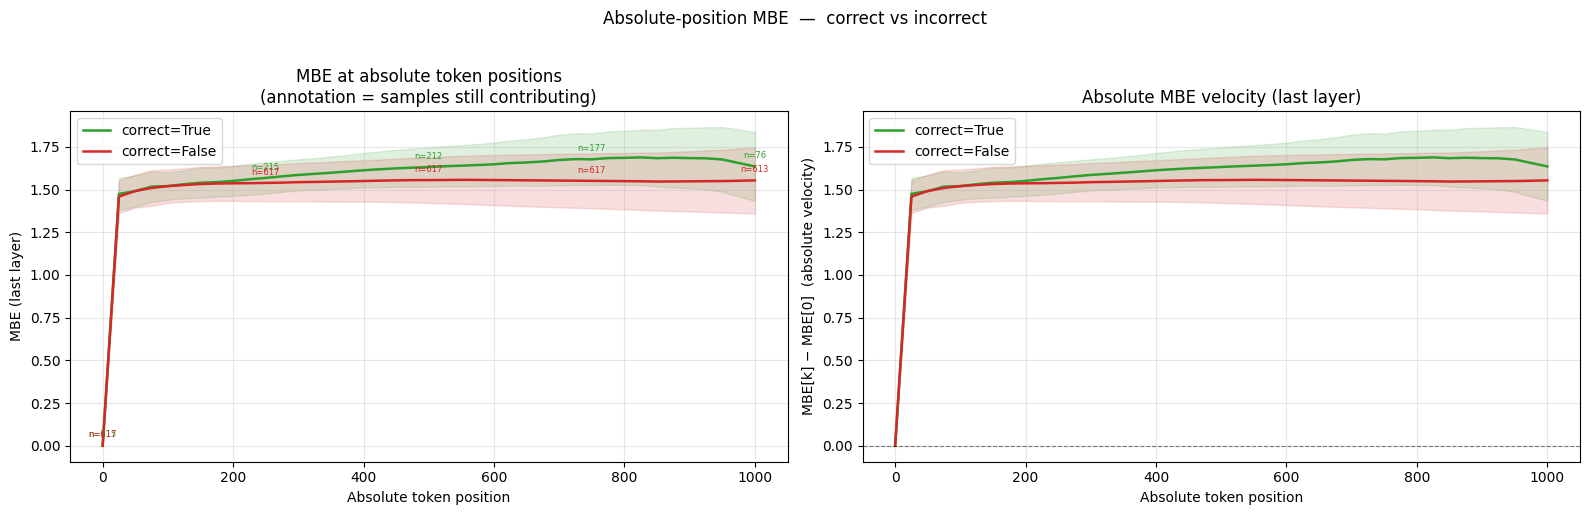

In [54]:

# ── Absolute-position MBE velocity ───────────────────────────────────────────
# At each absolute token index k, take all samples whose completion is longer
# than k, and compute MBE(last layer)[k] and velocity = MBE[k] - MBE[0].
# This avoids the percentile-normalization artifact caused by incorrect rollouts
# being ~always at the 1024-token cap while correct ones are much shorter.

ABS_STEP = 25
abs_positions = np.arange(0, 1025, ABS_STEP)

abs_mean_mbe = {True: [], False: []}
abs_std_mbe  = {True: [], False: []}
abs_mean_vel = {True: [], False: []}
abs_std_vel  = {True: [], False: []}
abs_n        = {True: [], False: []}

for pos in abs_positions:
    for label in [True, False]:
        vals_mbe, vals_vel = [], []
        for r in records:
            if r['correct'] != label:
                continue
            last = np.array(r['mbe'])[-1]
            if len(last) > pos:
                vals_mbe.append(last[pos])
                vals_vel.append(last[pos] - last[0])
        if vals_mbe:
            abs_mean_mbe[label].append(np.mean(vals_mbe))
            abs_std_mbe[label].append(np.std(vals_mbe))
            abs_mean_vel[label].append(np.mean(vals_vel))
            abs_std_vel[label].append(np.std(vals_vel))
            abs_n[label].append(len(vals_mbe))
        else:
            abs_mean_mbe[label].append(np.nan)
            abs_std_mbe[label].append(np.nan)
            abs_mean_vel[label].append(np.nan)
            abs_std_vel[label].append(np.nan)
            abs_n[label].append(0)

for label in [True, False]:
    abs_mean_mbe[label] = np.array(abs_mean_mbe[label])
    abs_std_mbe[label]  = np.array(abs_std_mbe[label])
    abs_mean_vel[label] = np.array(abs_mean_vel[label])
    abs_std_vel[label]  = np.array(abs_std_vel[label])
    abs_n[label]        = np.array(abs_n[label])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- panel 1: absolute MBE profile ---
ax = axes[0]
for label, color in [(True, 'tab:green'), (False, 'tab:red')]:
    mask = ~np.isnan(abs_mean_mbe[label])
    xs = abs_positions[mask]
    ys = abs_mean_mbe[label][mask]
    ns = abs_n[label][mask]
    es = abs_std_mbe[label][mask]
    ax.plot(xs, ys, color=color, linewidth=1.8, label=f'correct={label}')
    ax.fill_between(xs, ys - es, ys + es, color=color, alpha=0.15)
    # annotate n at selected positions
    for ann_pos in [0, 250, 500, 750, 1000]:
        idx = np.searchsorted(xs, ann_pos)
        if idx < len(xs):
            ax.annotate(f'n={ns[idx]}', xy=(xs[idx], ys[idx]),
                        xytext=(0, 6), textcoords='offset points',
                        fontsize=6, color=color, ha='center')

ax.set_xlabel('Absolute token position')
ax.set_ylabel('MBE (last layer)')
ax.set_title('MBE at absolute token positions\n(annotation = samples still contributing)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- panel 2: absolute velocity ---
ax = axes[1]
for label, color in [(True, 'tab:green'), (False, 'tab:red')]:
    mask = ~np.isnan(abs_mean_vel[label])
    xs = abs_positions[mask]
    ys = abs_mean_vel[label][mask]
    es = abs_std_vel[label][mask]
    ax.plot(xs, ys, color=color, linewidth=1.8, label=f'correct={label}')
    ax.fill_between(xs, ys - es, ys + es, color=color, alpha=0.15)

ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Absolute token position')
ax.set_ylabel('MBE[k] − MBE[0]  (absolute velocity)')
ax.set_title('Absolute MBE velocity (last layer)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Absolute-position MBE  —  correct vs incorrect', y=1.02)
plt.tight_layout()
plt.show()


correct=True : 167/215 have </think>, mean tok=662, std=139
correct=False: 139/617 have </think>, mean tok=878, std=76


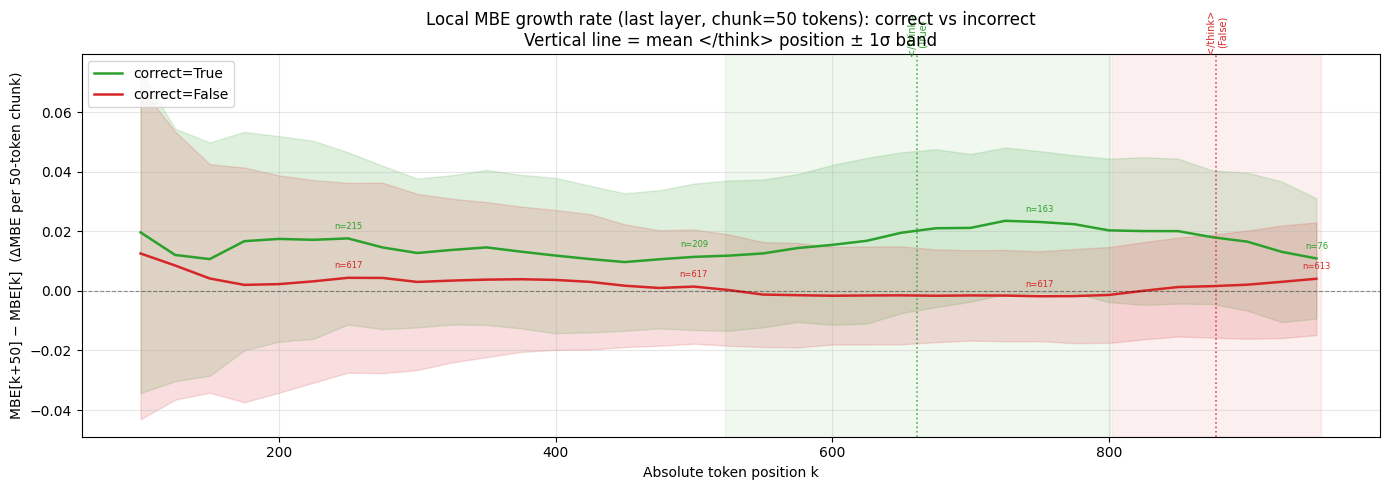

In [55]:

# ── Delta-MBE over fixed token chunk + </think> marker ───────────────────────
CHUNK  = 50
STRIDE = 25
START  = 100

start_positions = np.arange(START, 1025 - CHUNK, STRIDE)

delta_mean = {True: [], False: []}
delta_std  = {True: [], False: []}
delta_n    = {True: [], False: []}

for k in start_positions:
    for label in [True, False]:
        deltas = []
        for r in records:
            if r['correct'] != label:
                continue
            last = np.array(r['mbe'])[-1]
            if len(last) > k + CHUNK:
                deltas.append(last[k + CHUNK] - last[k])
        if deltas:
            delta_mean[label].append(np.mean(deltas))
            delta_std[label].append(np.std(deltas))
            delta_n[label].append(len(deltas))
        else:
            delta_mean[label].append(np.nan)
            delta_std[label].append(np.nan)
            delta_n[label].append(0)

for label in [True, False]:
    delta_mean[label] = np.array(delta_mean[label])
    delta_std[label]  = np.array(delta_std[label])
    delta_n[label]    = np.array(delta_n[label])

# ── locate </think> token position (approx via char-fraction × n_tokens) ─────
THINK_TAG = '</think>'
think_pos = {True: [], False: []}
for r in records:
    idx = r['response'].find(THINK_TAG)
    if idx != -1:
        approx_tok = int(idx / len(r['response']) * r['n_tokens'])
        think_pos[r['correct']].append(approx_tok)

for label in [True, False]:
    total = sum(1 for r in records if r['correct'] == label)
    tp = think_pos[label]
    msg = (f"correct={str(label):5s}: {len(tp)}/{total} have {THINK_TAG}, "
           f"mean tok={np.mean(tp):.0f}, std={np.std(tp):.0f}" if tp else
           f"correct={str(label):5s}: 0/{total} have {THINK_TAG}")
    print(msg)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

for label, color in [(True, 'tab:green'), (False, 'tab:red')]:
    mask = ~np.isnan(delta_mean[label])
    xs = start_positions[mask]
    ys = delta_mean[label][mask]
    es = delta_std[label][mask]
    ns = delta_n[label][mask]
    ax.plot(xs, ys, color=color, linewidth=1.8, label=f'correct={label}')
    ax.fill_between(xs, ys - es, ys + es, color=color, alpha=0.15)
    for ann_pos in [250, 500, 750, 950]:
        idx = np.searchsorted(xs, ann_pos)
        if idx < len(xs):
            ax.annotate(f'n={ns[idx]}', xy=(xs[idx], ys[idx]),
                        xytext=(0, 7), textcoords='offset points',
                        fontsize=6, color=color, ha='center')

    # </think> vertical band
    tp = think_pos[label]
    if tp:
        mu, sigma = np.mean(tp), np.std(tp)
        ax.axvline(mu, color=color, linewidth=1.2, linestyle=':', alpha=0.8)
        ax.axvspan(mu - sigma, mu + sigma, color=color, alpha=0.07)
        ax.text(mu, ax.get_ylim()[1] if ax.get_ylim()[1] != 1.0 else 0,
                f'</think>\n({label})', color=color, fontsize=7,
                ha='center', va='bottom', rotation=90)

ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_xlabel('Absolute token position k')
ax.set_ylabel(f'MBE[k+{CHUNK}] − MBE[k]  (ΔMBE per {CHUNK}-token chunk)')
ax.set_title(f'Local MBE growth rate (last layer, chunk={CHUNK} tokens): correct vs incorrect\n'
             f'Vertical line = mean </think> position ± 1σ band')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Sequences used: 296   skipped (no </think> or too short): 536

correct=True  n=161
  <think> segment  : len=  639± 124 tok  mean_MBE=1.58902  slope=+0.000297/tok
  answer  segment  : len=  203±  47 tok  mean_MBE=1.76540  slope=+0.000910/tok

correct=False  n=135
  <think> segment  : len=  864±  73 tok  mean_MBE=1.60170  slope=+0.000196/tok
  answer  segment  : len=  146±  66 tok  mean_MBE=1.71640  slope=+0.000643/tok



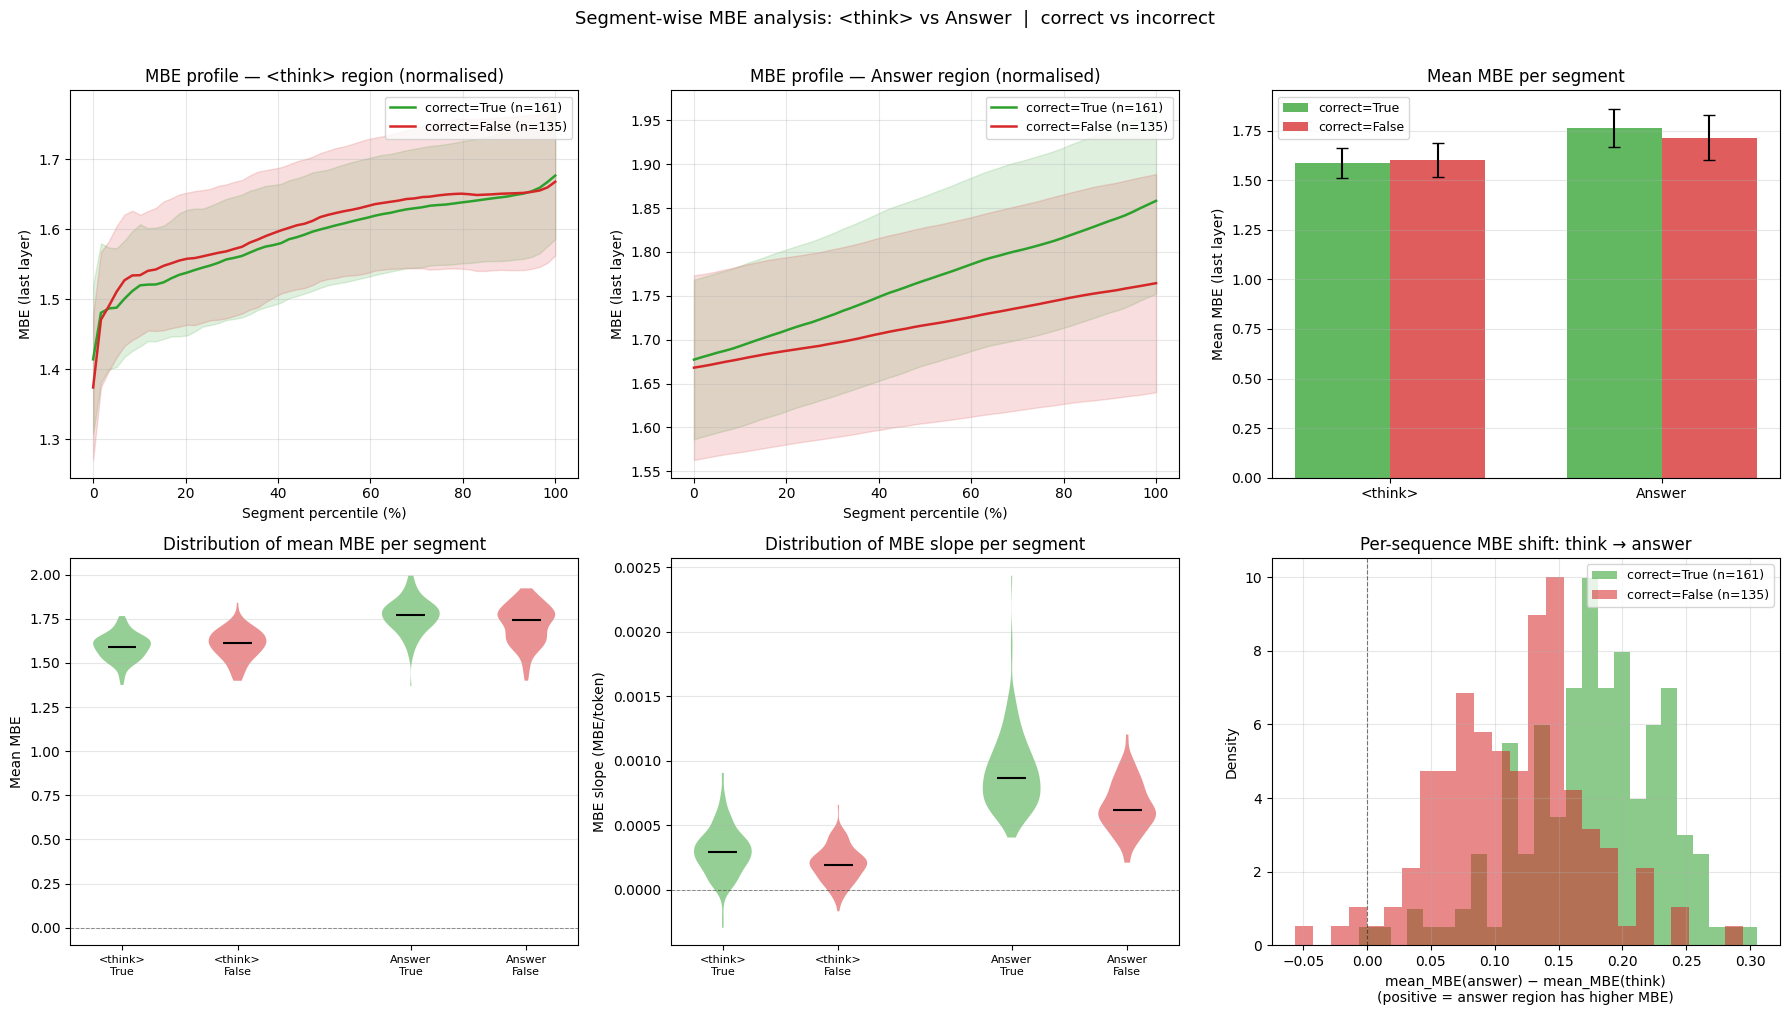

In [56]:

# ── Segment-wise MBE analysis: <think> region vs answer region ───────────────
CLOSE_TAG = '</think>'
SKIP      = 10
MIN_SEG   = 30
PCT_GRID  = 60

pct_ax = np.linspace(0, 100, PCT_GRID)

think_curves  = {True: [], False: []}
answer_curves = {True: [], False: []}
think_means   = {True: [], False: []}
answer_means  = {True: [], False: []}
think_slopes  = {True: [], False: []}
answer_slopes = {True: [], False: []}
think_lens    = {True: [], False: []}
answer_lens   = {True: [], False: []}

n_used = n_skipped = 0
for r in records:
    resp  = r['response']
    ntok  = r['n_tokens']
    last  = np.array(r['mbe'])[-1]
    label = r['correct']

    close_idx = resp.find(CLOSE_TAG)
    if close_idx == -1:
        n_skipped += 1
        continue

    close_tok  = int(close_idx / len(resp) * ntok)
    think_seg  = last[SKIP : close_tok]
    answer_seg = last[close_tok :]

    if len(think_seg) < MIN_SEG or len(answer_seg) < MIN_SEG:
        n_skipped += 1
        continue

    n_used += 1
    think_curves[label].append(
        np.interp(pct_ax, np.linspace(0, 100, len(think_seg)), think_seg))
    answer_curves[label].append(
        np.interp(pct_ax, np.linspace(0, 100, len(answer_seg)), answer_seg))

    think_means[label].append(float(np.mean(think_seg)))
    answer_means[label].append(float(np.mean(answer_seg)))
    think_slopes[label].append(float(np.polyfit(np.arange(len(think_seg)),  think_seg, 1)[0]))
    answer_slopes[label].append(float(np.polyfit(np.arange(len(answer_seg)), answer_seg, 1)[0]))
    think_lens[label].append(len(think_seg))
    answer_lens[label].append(len(answer_seg))

print(f"Sequences used: {n_used}   skipped (no </think> or too short): {n_skipped}\n")
CLR = {True: 'tab:green', False: 'tab:red'}

for label in [True, False]:
    n = len(think_means[label])
    if n == 0:
        continue
    print(f"correct={label}  n={n}")
    print(f"  <think> segment  : len={np.mean(think_lens[label]):5.0f}±{np.std(think_lens[label]):4.0f} tok  "
          f"mean_MBE={np.mean(think_means[label]):.5f}  slope={np.mean(think_slopes[label]):+.6f}/tok")
    print(f"  answer  segment  : len={np.mean(answer_lens[label]):5.0f}±{np.std(answer_lens[label]):4.0f} tok  "
          f"mean_MBE={np.mean(answer_means[label]):.5f}  slope={np.mean(answer_slopes[label]):+.6f}/tok")
    print()

# ── plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- row 0: MBE profiles (percentile-normalised) ---
for col, (seg_curves, seg_label) in enumerate([
        (think_curves,  '<think> region (normalised)'),
        (answer_curves, 'Answer region (normalised)'),
]):
    ax = axes[0, col]
    for label in [True, False]:
        if not seg_curves[label]:
            continue
        arr  = np.stack(seg_curves[label])
        mean = arr.mean(axis=0)
        std  = arr.std(axis=0)
        ax.plot(pct_ax, mean, color=CLR[label], linewidth=1.8,
                label=f'correct={label} (n={len(arr)})')
        ax.fill_between(pct_ax, mean - std, mean + std, color=CLR[label], alpha=0.15)
    ax.set_xlabel('Segment percentile (%)')
    ax.set_ylabel('MBE (last layer)')
    ax.set_title(f'MBE profile — {seg_label}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# --- row 0, col 2: mean MBE per segment bar chart ---
ax = axes[0, 2]
x = np.arange(2)
width = 0.35
for i, label in enumerate([True, False]):
    vals = [np.mean(think_means[label])  if think_means[label]  else 0,
            np.mean(answer_means[label]) if answer_means[label] else 0]
    errs = [np.std(think_means[label])   if think_means[label]  else 0,
            np.std(answer_means[label])  if answer_means[label] else 0]
    ax.bar(x + (i - 0.5) * width, vals, width, color=CLR[label], alpha=0.75,
           yerr=errs, capsize=4, label=f'correct={label}')
ax.set_xticks(x)
ax.set_xticklabels(['<think>', 'Answer'])
ax.set_ylabel('Mean MBE (last layer)')
ax.set_title('Mean MBE per segment')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# --- row 1: violin plots ---
# build data dicts explicitly (dict comprehension can't emit 2 k-v pairs per iteration)
mean_mbe_dict = {}
slope_dict    = {}
for lbl in [True, False]:
    mean_mbe_dict[(lbl, 'think')]  = think_means[lbl]
    mean_mbe_dict[(lbl, 'answer')] = answer_means[lbl]
    slope_dict[(lbl, 'think')]     = think_slopes[lbl]
    slope_dict[(lbl, 'answer')]    = answer_slopes[lbl]

for col, (data_dict, ylabel, title) in enumerate([
    (mean_mbe_dict, 'Mean MBE',              'Distribution of mean MBE per segment'),
    (slope_dict,    'MBE slope (MBE/token)', 'Distribution of MBE slope per segment'),
]):
    ax = axes[1, col]
    positions, vdata, xtick_labs, colors_v = [], [], [], []
    pos = 1
    for seg in ['think', 'answer']:
        for lbl in [True, False]:
            d = data_dict[(lbl, seg)]
            if d:
                positions.append(pos)
                vdata.append(d)
                xtick_labs.append(f'{"<think>" if seg == "think" else "Answer"}\n{lbl}')
                colors_v.append(CLR[lbl])
            pos += 1
        pos += 0.5
    vp = ax.violinplot(vdata, positions=positions, showmedians=True, showextrema=False)
    for body, c in zip(vp['bodies'], colors_v):
        body.set_facecolor(c)
        body.set_alpha(0.5)
    vp['cmedians'].set_color('k')
    ax.axhline(0, color='k', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.set_xticks(positions)
    ax.set_xticklabels(xtick_labs, fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis='y')

# --- row 1, col 2: per-sequence MBE shift (answer - think) ---
ax = axes[1, 2]
for label in [True, False]:
    deltas = [am - tm for tm, am in zip(think_means[label], answer_means[label])]
    ax.hist(deltas, bins=25, alpha=0.55, color=CLR[label], density=True,
            label=f'correct={label} (n={len(deltas)})')
ax.axvline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('mean_MBE(answer) − mean_MBE(think)\n(positive = answer region has higher MBE)')
ax.set_ylabel('Density')
ax.set_title('Per-sequence MBE shift: think → answer')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Segment-wise MBE analysis: <think> vs Answer  |  correct vs incorrect',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
